In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("Advertising.xls").drop(columns=["Unnamed: 0"])

In [5]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


<Axes: xlabel='TV', ylabel='Count'>

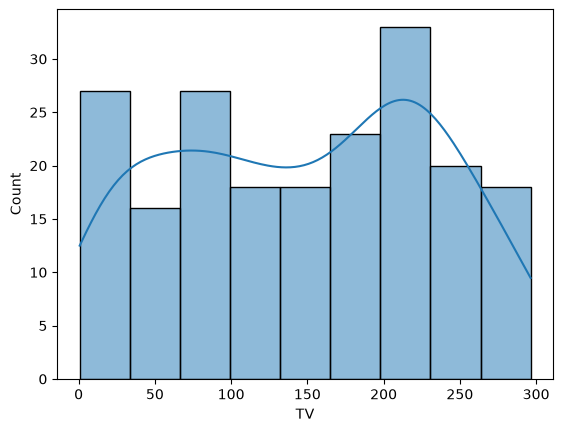

In [6]:
sns.histplot(df,x="TV",kde=True)

<Axes: xlabel='TV', ylabel='Newspaper'>

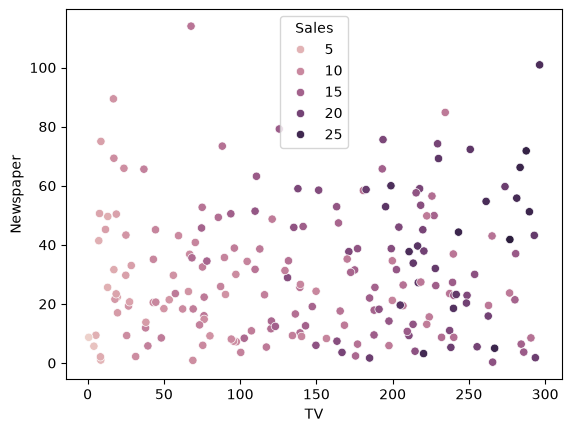

In [7]:
sns.scatterplot(df,x="TV",y="Newspaper",hue="Sales")

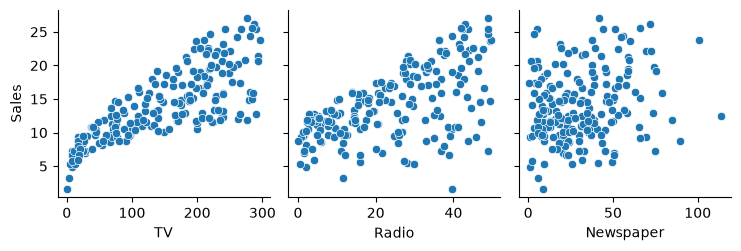

In [8]:


# 2. Relationships with Sales
sns.pairplot(df, y_vars=['Sales'], x_vars=['TV', 'Radio', 'Newspaper'])
plt.show()



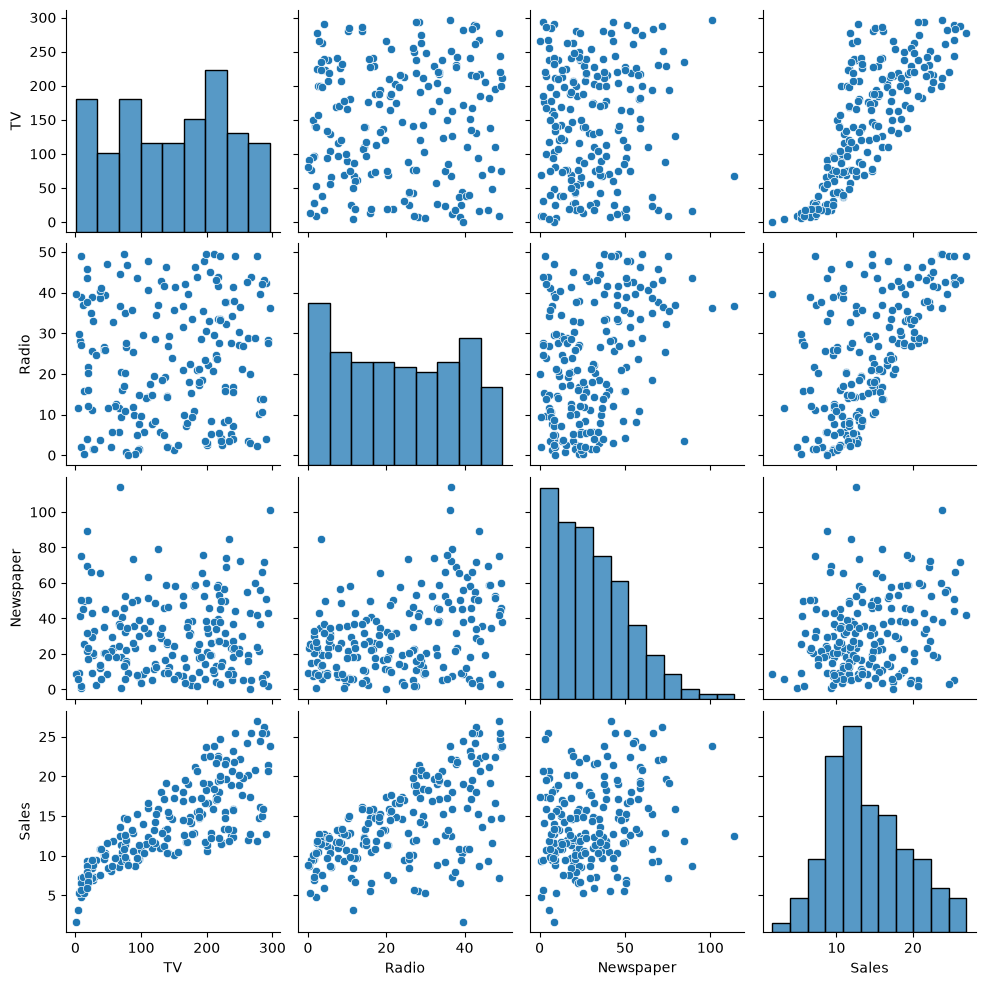

In [9]:
sns.pairplot(df)
plt.show()

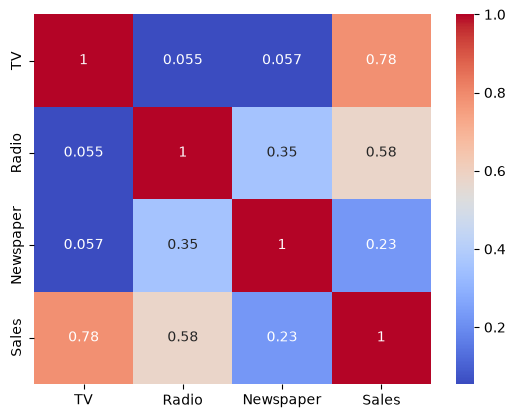

In [10]:
# 1. Correlation
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [12]:
X=df.drop("Sales",axis=1)
y=df["Sales"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [14]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [15]:
model=LinearRegression()
model.fit(X_train_scaled,y_train)
y_pred=model.predict(X_test_scaled)

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 1.4607567168117601
MSE: 3.1740973539761073
RMSE: 1.781599661533451
R²: 0.8994380241009119


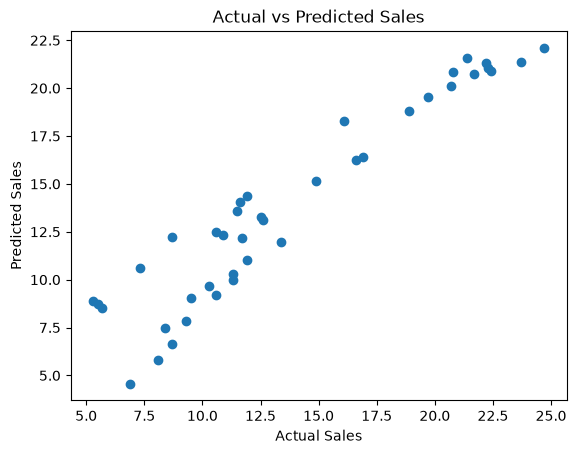

In [17]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

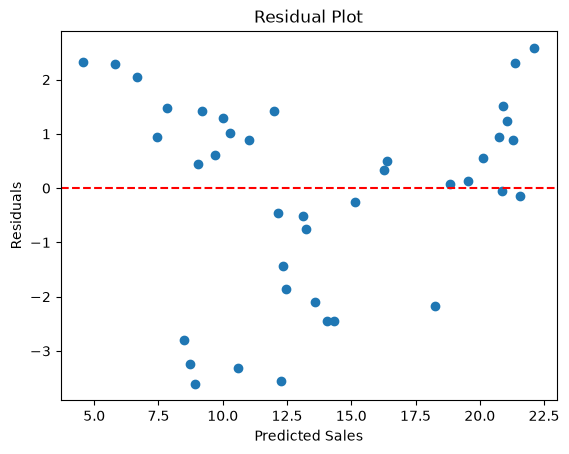

In [18]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [19]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("R²:", r2_score(y_test, y_pred_gb))
print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))

R²: 0.9833065804358095
MAE: 0.6084372924225304
RMSE: 0.7258817489249954


In [20]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    gb,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("R² scores:", scores)
print("Mean R²:", scores.mean())

R² scores: [0.98111453 0.98790689 0.96937207 0.96544383 0.98713761]
Mean R²: 0.9781949859170324


___
___

## Linear Regression and SSE calculation

___
___

## TV SSE

In [21]:
X = df.TV.to_numpy()
y = df.Sales.to_numpy()

In [22]:
x_mean = X.mean()
y_mean = y.mean()

beta_1 = np.sum((X - x_mean) * (y -y_mean)/ np.sum(np.power((X -x_mean),2)))
print(beta_1)

0.047536640433019736


In [23]:
beta_0 = y_mean - (beta_1 *x_mean)
beta_0

np.float64(7.0325935491276965)

In [24]:
print(f"y = {beta_0 : .3f} + {beta_1 : .3f}x ")

y =  7.033 +  0.048x 


In [25]:
y_hat = beta_0 + (beta_1 * X)

In [26]:
sse = np.sum(np.power((y - y_hat),2))

In [27]:
sse

np.float64(2102.5305831313512)

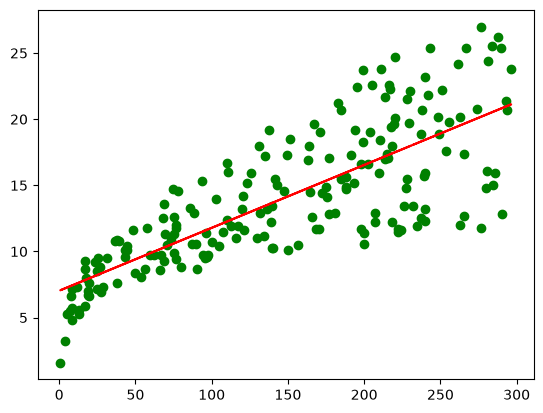

In [28]:
plt.scatter(X,y,color = "green")
plt.plot(X, beta_0 + (beta_1 * X), color = "red")

___
___

## Radio SSE

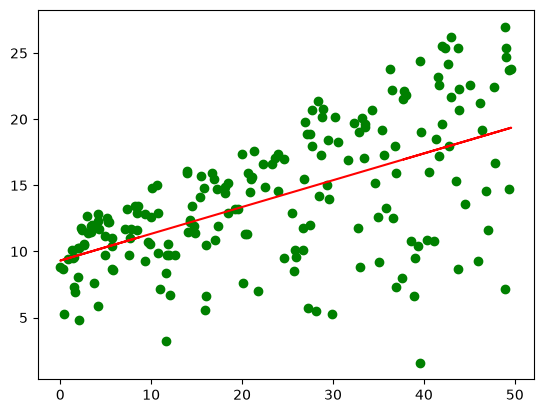

In [29]:
X = df.Radio.to_numpy()
y = df.Sales.to_numpy()

x_mean = X.mean()
y_mean = y.mean()

beta_1 = np.sum((X - x_mean) * (y -y_mean)/ np.sum(np.power((X -x_mean),2)))

beta_0 = y_mean - (beta_1 * x_mean)

plt.scatter(X,y,color = "green")
plt.plot(X, beta_0 + (beta_1 * X), color = "red")

___
___

## Newspaper SSE

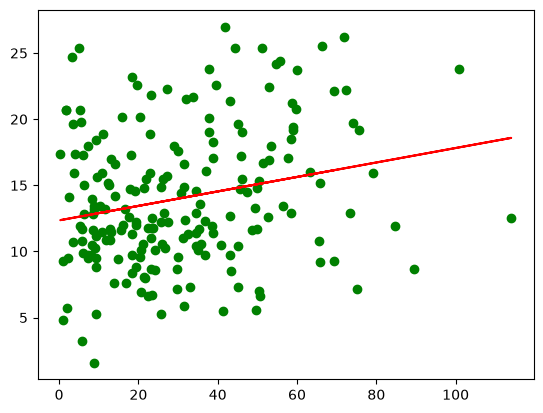

In [30]:
X = df.Newspaper.to_numpy()
y = df.Sales.to_numpy()

x_mean = X.mean()
y_mean = y.mean()

beta_1 = np.sum((X - x_mean) * (y -y_mean)/ np.sum(np.power((X -x_mean),2)))

beta_0 = y_mean - (beta_1 * x_mean)

plt.scatter(X,y,color = "green")
plt.plot(X, beta_0 + (beta_1 * X), color = "red")

___
___

## Performance Metrics

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [32]:
X = df[["TV"]].to_numpy()
y = df[["Sales"]].to_numpy()

In [33]:
X_train , X_test ,y_train ,y_test = train_test_split(X, y ,test_size= 0.2, random_state= 999)

In [34]:
X_train.shape

(160, 1)

In [35]:
X_test.shape

(40, 1)

___
___

In [36]:
lr=LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[0.05]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[6.83]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[1080.34]


In [37]:
y_hat = lr.predict(X_train)
sse = np.sum(np.power((y_train - y_hat),2))

In [38]:
sse

np.float64(1573.6202339696292)